In [2]:
import numpy as np
import csv
import random
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
import seaborn as sns

In [3]:
genes = []
data = []

with open("GSE150910_gene-level_count_file.csv") as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    for row in reader:
        
        genes.append(row[0])
        data.append(row[1:])

In [4]:
samples = data[0]
data = data[1:]
genes = genes[1:]

In [5]:
data = np.array(data).astype(float)
genes = np.array(genes)
samples = np.array(samples)

In [6]:
print(genes.shape)
print(samples.shape)
print(data.shape)

(18838,)
(288,)
(18838, 288)


In [7]:
print("genes:")
print(genes[0:5])
print()

print("samples:")
print(samples[0:4])
print()


print("data:")
print(data[0:5,0:4])
print()

genes:
['TSPAN6' 'TNMD' 'DPM1' 'SCYL3' 'C1orf112']

samples:
['chp_26' 'chp_31' 'chp_34' 'chp_38']

data:
[[1361.  993.  351.  613.]
 [   5.   13.    0.    0.]
 [1929. 2775. 1894. 2007.]
 [ 176.  216.  208.  218.]
 [  93.  143.   97.  148.]]



In [8]:
labels = []

for i in range(len(samples)):
    tmp = samples[i].split("_")
    labels.append(tmp[0])
    
labels = np.array(labels)

In [9]:
print(labels[0:5])

print(np.unique(labels))

['chp' 'chp' 'chp' 'chp' 'chp']
['chp' 'control' 'ipf']


In [10]:
data = data[:  ,labels != "chp"]
samples = samples[labels != "chp"]
labels = labels[labels != "chp"]

In [11]:
print(data.shape)
print(samples.shape)
print(labels.shape)

(18838, 206)
(206,)
(206,)


In [12]:
for j in range(data.shape[1]):
    column_sum = sum(data[:,j])
    
    data[:,j] = data[:,j] / column_sum * 1000000

In [13]:
print(data)

[[2.62026354e+01 3.98260770e+01 3.24569396e+01 ... 3.31761577e+01
  3.12351859e+01 3.07286955e+01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.82286581e-01
  0.00000000e+00 0.00000000e+00]
 [7.37006988e+01 8.12189622e+01 5.73764856e+01 ... 6.33142058e+01
  6.77984395e+01 6.99859061e+01]
 ...
 [1.23451757e-01 2.91499191e-01 1.92280448e-01 ... 3.03810968e-02
  1.46644065e-01 1.62757921e-01]
 [1.82091341e+00 2.76924232e+00 1.42287531e+00 ... 1.79248471e+00
  1.80861014e+00 2.05074981e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]


In [14]:
mean_CPM_control = data[:,labels == "control"].mean(axis=1)
mean_CPM_ipf = data[:,labels == "ipf"].mean(axis=1)

to_keep = (mean_CPM_ipf >= 5) | (mean_CPM_control >= 5)

data = data[to_keep,:]
genes = genes[to_keep]

print(data.shape)
print(len(genes))

(11097, 206)
11097


In [15]:
control = data[0, labels == "control"]
ipf = data[0, labels == "ipf"]

In [16]:
print(control.shape)
print(ipf.shape)

(103,)
(103,)


In [17]:
ks_statistic, p_value = ks_2samp(control, ipf)

print(ks_statistic)
print(p_value)

0.4368932038834951
3.264129457102852e-09


In [18]:
epsilon = 1  # small constant to avoid division by zero

control_mean = np.mean(control)
ipf_mean = np.mean(ipf)

# calculate log2(fold change), adding epsilon to avoid division by 0
FC = (ipf_mean + epsilon) / (control_mean + epsilon)
log2_FC = np.log2(FC)

print(log2_FC)

0.7894289821093974


In [19]:
# getting p-value and log2FC, now for every gene

p_values = []
log2_FCs = []

epsilon = 1  # small constant to avoid division by zero

for i in range(data.shape[0]):
    
    control = data[i, labels == "control"]
    ipf = data[i, labels == "ipf"]

    # perform ks-test
    ks_statistic, p_value = ks_2samp(control, ipf)

    # save p_value for this gene
    p_values.append(p_value)


    # calculate means for each condition
    control_mean = np.mean(control)
    ipf_mean = np.mean(ipf)

    # calculate log2(fold change), adding epsilon to avoid division by 0
    FC = (ipf_mean + epsilon) / (control_mean + epsilon)
    log2_FC = np.log2(FC)
    
    # save log2_FC for this gene
    log2_FCs.append(log2_FC)


# cast results to numpy arrays
p_values = np.array(p_values)
log2_FCs = np.array(log2_FCs)

In [20]:
print(log2_FCs)

[ 0.78942898  0.10099232  0.02098811 ...  0.17873364 -0.38355766
  0.49471926]


In [21]:
p_values_bonf = p_values * len(genes)

In [22]:
to_keep = (p_values_bonf <= 0.05) & (np.abs(log2_FCs) >= 2)

sig_genes = genes[to_keep]
sig_log2_FCs = log2_FCs[to_keep]
sig_p_values_bonf = p_values_bonf[to_keep]
sig_data = data[to_keep, :]

In [23]:
print(f"Number of DEGs: {len(sig_genes)}")
print(f"Total number of genes: {len(genes)}")
print(f"DEG percentage: {len(sig_genes) / len(genes) * 100}")
print()
print(f"Number of upregulated DEGs: {np.sum(sig_log2_FCs>0)}")
print(f"Number of downregulated DEGs: {np.sum(sig_log2_FCs<0)}")

Number of DEGs: 79
Total number of genes: 11097
DEG percentage: 0.7119041182301523

Number of upregulated DEGs: 65
Number of downregulated DEGs: 14


In [24]:
for i in range(len(sig_genes)):
    if sig_log2_FCs[i] > 0:
        print(sig_genes[i])

PROM1
CYP24A1
CP
CDH3
COL17A1
ATP12A
FAT2
SLC4A11
DERL3
VSIG1
CD79A
COMP
COL1A1
COL7A1
FHL2
TSPAN1
MUC5B
SPP1
IL13RA2
COL10A1
BPIFB1
PDLIM4
TNS4
FCRLA
JCHAIN
POSTN
ERN2
TMPRSS4
STRA6
GPR87
FCRL5
MUC4
CXCL14
FAM83A
PLEKHS1
SYT8
THY1
CXCL13
MS4A1
SCGB3A1
CTHRC1
CLDN2
GREM1
UGT1A6
COL3A1
SPRR1A
MZB1
KRT15
LGALS7B
B3GNT3
MUC16
FDCSP
ALDH1A3
COL14A1
PLA2G2A
S100A2
BPIFA1
IGFL2
LGALS7
SERPINB4
DIO2
IGLL5
AC136428.1
MSMB
PRSS2


In [25]:
for i in range(len(sig_genes)):
    if sig_log2_FCs[i] < 0:
        print(sig_genes[i])

PRX
SLC6A4
MYRF
FCN3
GGTLC1
ITLN2
DEFA4
BTNL9
MS4A15
CA4
RTKN2
AGER
DEFA1
DEFA1B


In [26]:
sig_data_log2fc = np.zeros_like(sig_data)

print(sig_data.shape)

(79, 206)


In [27]:
epsilon = 1  # small constant to avoid division by zero


for i in range(len(sig_genes)):
    
    control_mean =  np.mean(sig_data[i,labels == "control"])
    
    sig_data_log2fc[i,:] = np.log2((sig_data[i,:]+epsilon) / (control_mean +epsilon))

C:\Users\hp\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\hp\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


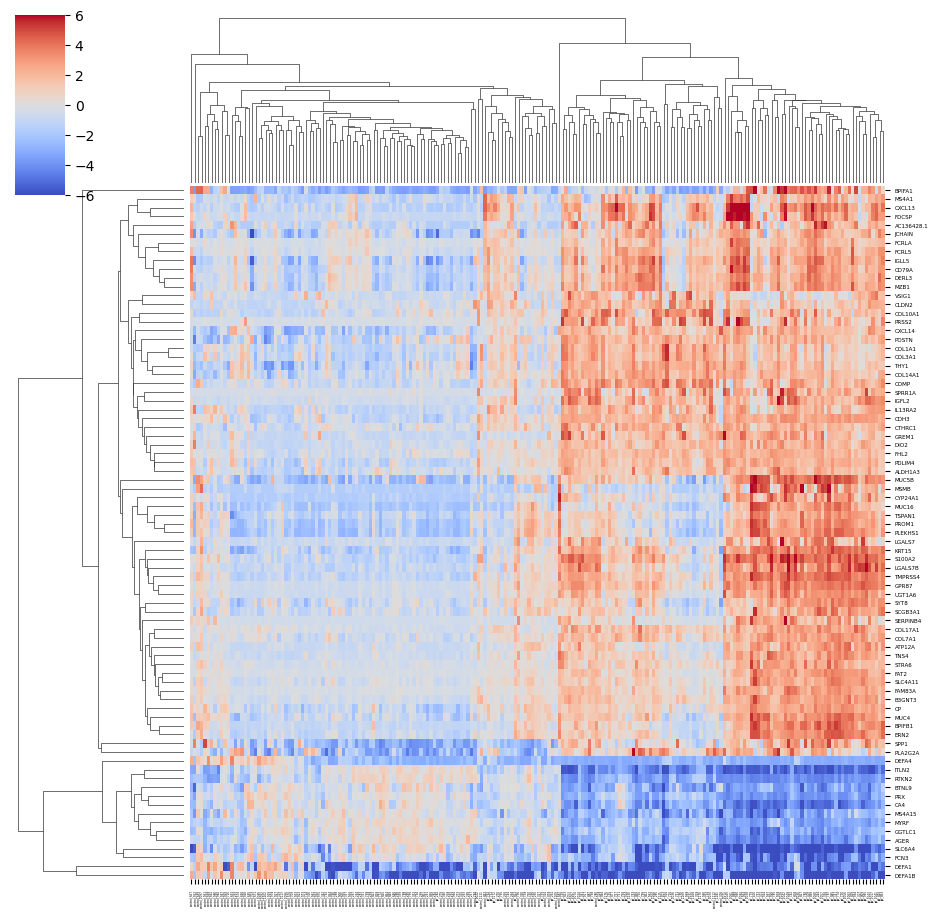

In [28]:
sns_plot = sns.clustermap(sig_data_log2fc, xticklabels=samples, yticklabels= sig_genes, cmap="coolwarm", vmin=-6, vmax=6)

# changing font sizes for x and y labels
sns_plot.ax_heatmap.set_xticklabels(sns_plot.ax_heatmap.get_xmajorticklabels(), fontsize=2)
sns_plot.ax_heatmap.set_yticklabels(sns_plot.ax_heatmap.get_ymajorticklabels(), fontsize=4)


sns_plot.savefig("transcriptomics_heatmap.png")

plt.show()

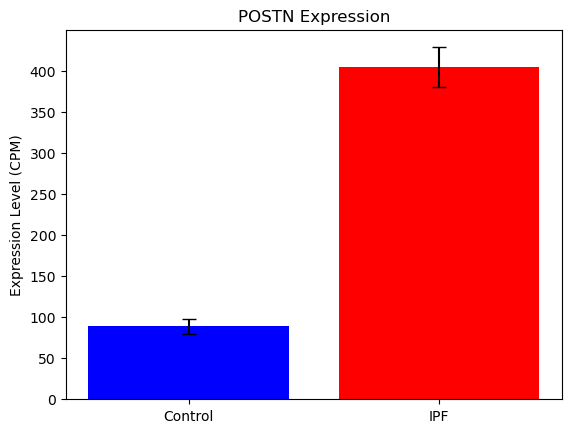

In [29]:
#More visualisations
## expression bar plot

gene_to_plot = "POSTN"

control_expression = data[genes==gene_to_plot, labels == "control"]
ipf_expression = data[genes==gene_to_plot, labels == "ipf"]

control_mean = np.mean(control_expression)
control_sem = np.std(control_expression) / np.sqrt(len(control_expression))
ipf_mean = np.mean(ipf_expression)
ipf_sem = np.std(ipf_expression) / np.sqrt(len(ipf_expression))

conditions = ['Control', 'IPF']
means = [control_mean, ipf_mean]
errors = [control_sem, ipf_sem]

plt.bar(conditions, means, yerr=errors, capsize=5, color=['blue', 'red'])
plt.ylabel('Expression Level (CPM)')
plt.title(f'{gene_to_plot} Expression')
# plt.savefig(f"output/{gene_to_plot}_expression_bar.pdf")
plt.show()

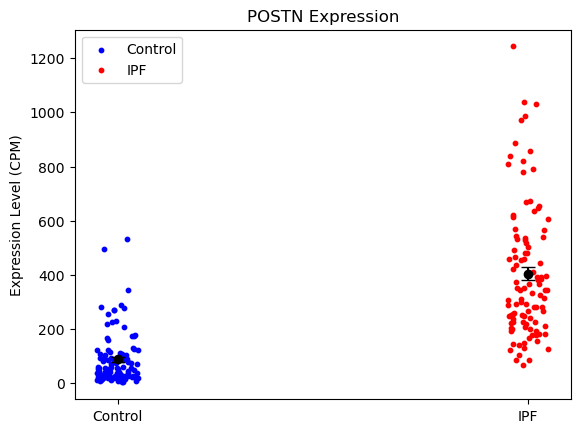

In [30]:
# expression scatter plot

gene_to_plot = "POSTN"

control_expression = data[genes == gene_to_plot, labels == "control"]
ipf_expression = data[genes == gene_to_plot, labels == "ipf"]

control_mean = np.mean(control_expression)
control_sem = np.std(control_expression) / np.sqrt(len(control_expression))
ipf_mean = np.mean(ipf_expression)
ipf_sem = np.std(ipf_expression) / np.sqrt(len(ipf_expression))

def add_jitter(values, jitter_amount=0.05):
    return values + np.random.uniform(-jitter_amount, jitter_amount, size=values.shape)

control_x = add_jitter(np.ones_like(control_expression) * 1) 
ipf_x = add_jitter(np.ones_like(ipf_expression) * 2)

plt.scatter(control_x, control_expression, color='blue', label='Control', s=10)  # smaller dots with s=10
plt.scatter(ipf_x, ipf_expression, color='red', label='IPF', s=10)  # smaller dots with s=10

plt.errorbar(1, control_mean, yerr=control_sem, fmt='o', color='black', capsize=5)
plt.errorbar(2, ipf_mean, yerr=ipf_sem, fmt='o', color='black', capsize=5)

plt.xticks([1, 2], ['Control', 'IPF'])

plt.ylabel('Expression Level (CPM)')
plt.title(f'{gene_to_plot} Expression')
plt.legend()

# plt.savefig(f"output/{gene_to_plot}_expression_scatter.pdf")
plt.show()

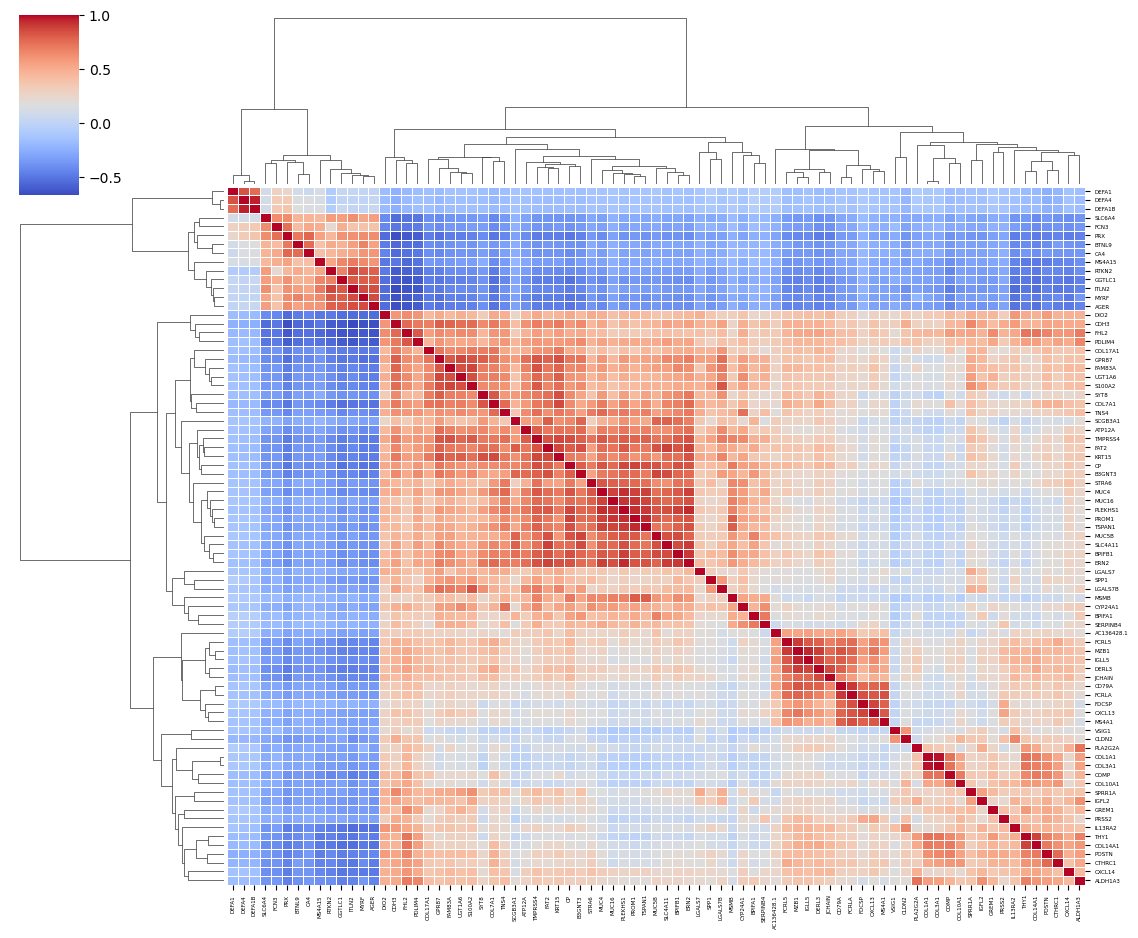

In [31]:
# DEG expression correlation

correlation_matrix = np.corrcoef(sig_data)

sns_plot = sns.clustermap(correlation_matrix, 
                          xticklabels=sig_genes, 
                          yticklabels=sig_genes, 
                          cmap="coolwarm", 
                          annot=False, 
                          linewidths=.5, 
                          figsize=(12, 10))

sns_plot.ax_heatmap.set_xticklabels(sns_plot.ax_heatmap.get_xmajorticklabels(), fontsize=4)
sns_plot.ax_heatmap.set_yticklabels(sns_plot.ax_heatmap.get_ymajorticklabels(), fontsize=4)

# sns_plot.savefig("output/degs_correlation_heatmap.pdf")
plt.show()